In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target.astype(int)

# Normalize pixel values (optional but helpful)
X = X / 255.0

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
components_list = [2, 10, 30, 50]
pca_models = {}
X_train_pca = {}
X_test_pca = {}

for n in components_list:
    pca = PCA(n_components=n)

    X_train_pca[n] = pca.fit_transform(X_train_scaled)
    X_test_pca[n] = pca.transform(X_test_scaled)

    pca_models[n] = pca

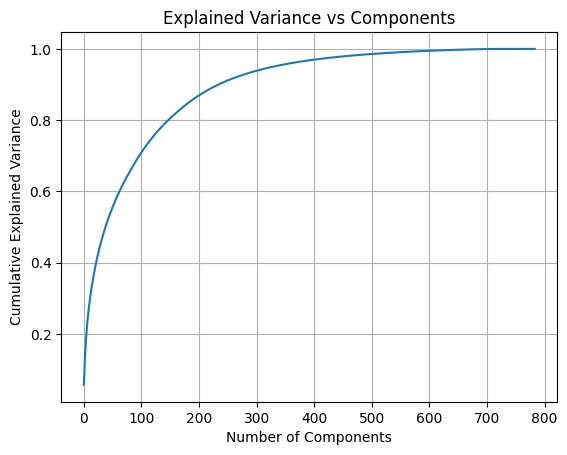

In [6]:
pca_full = PCA().fit(X_train_scaled)

plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Components")
plt.grid()
plt.show()

In [7]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)
y_pred_original = lr.predict(X_test_scaled)

original_acc = accuracy_score(y_test, y_pred_original)
print("Original Accuracy:", original_acc)

Original Accuracy: 0.9154285714285715


In [8]:
pca_accuracies = {}

for n in components_list:
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_pca[n], y_train)

    y_pred = lr.predict(X_test_pca[n])
    acc = accuracy_score(y_test, y_pred)

    pca_accuracies[n] = acc
    print(f"PCA ({n} components) Accuracy:", acc)

PCA (2 components) Accuracy: 0.3357142857142857
PCA (10 components) Accuracy: 0.8019285714285714
PCA (30 components) Accuracy: 0.8940714285714285
PCA (50 components) Accuracy: 0.9058571428571428


In [11]:
import pandas as pd

# Choose best component count (example: 50)
n = 50

train_df = pd.DataFrame(X_train_pca[n])
train_df['label'] = y_train.values

test_df = pd.DataFrame(X_test_pca[n])
test_df['label'] = y_test.values

# Save to CSV
train_df.to_csv("train_pca_50.csv", index=False)
test_df.to_csv("test_pca_50.csv", index=False)

print("Reduced datasets saved successfully!")

Reduced datasets saved successfully!


In [9]:
print("\n--- Accuracy Comparison ---")
print("Original:", original_acc)

for n, acc in pca_accuracies.items():
    print(f"PCA {n}:", acc)


--- Accuracy Comparison ---
Original: 0.9154285714285715
PCA 2: 0.3357142857142857
PCA 10: 0.8019285714285714
PCA 30: 0.8940714285714285
PCA 50: 0.9058571428571428


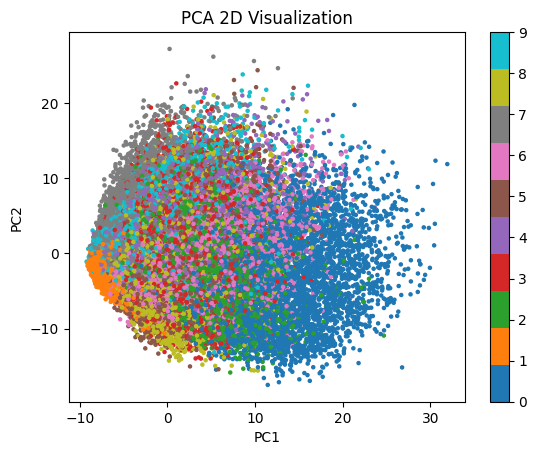

In [10]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure()
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("PCA 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()